In [3]:
import pandas as pd

df = pd.read_csv("BankNote_Authentication.csv")
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [4]:
df.shape

(1372, 5)

In [5]:
df.isnull().sum(), df['class'].value_counts()

(variance    0
 skewness    0
 curtosis    0
 entropy     0
 class       0
 dtype: int64,
 class
 0    762
 1    610
 Name: count, dtype: int64)

In [6]:
X = df.drop('class', axis=1)
y = df['class']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
X_train.shape

(1097, 4)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation="relu", input_dim=4),
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5074 - loss: 0.7182 - val_accuracy: 0.7000 - val_loss: 0.6671
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7685 - loss: 0.6327 - val_accuracy: 0.8273 - val_loss: 0.6044
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8426 - loss: 0.5717 - val_accuracy: 0.8273 - val_loss: 0.5481
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8655 - loss: 0.5094 - val_accuracy: 0.8455 - val_loss: 0.4838
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8723 - loss: 0.4367 - val_accuracy: 0.8545 - val_loss: 0.4122
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8940 - loss: 0.3632 - val_accuracy: 0.8818 - val_loss: 0.3468
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9133 - loss: 0.3002 - val_accuracy: 0.9136 - val_loss: 0.2925
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9339 - loss: 0.2481 - val_accuracy: 0.9318 - val_loss

In [15]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
test_accuracy

0.996363639831543

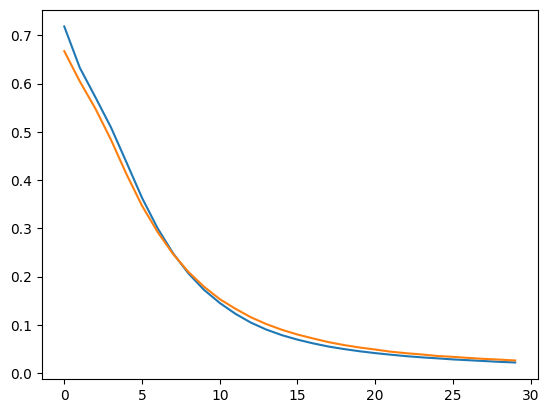

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

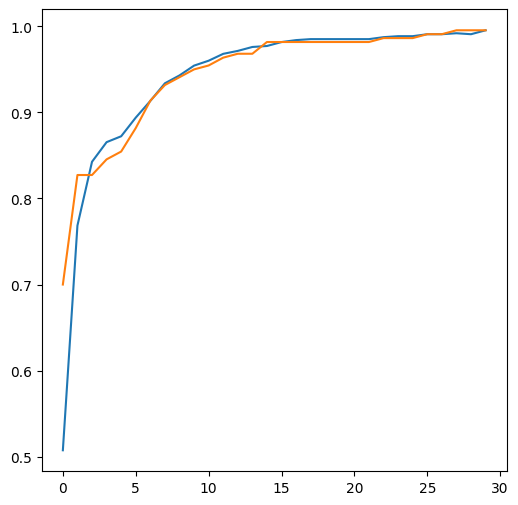

In [18]:
plt.figure(figsize = (6,6))
plt.plot(history.history['accuracy'],label = "train Acc")
plt.plot(history.history['val_accuracy'],label = "val Acc")

**Forward and backpropagation**


*   During forward propagation, the input moves through each layer to produce a prediction, and the loss function measures its error.
*   During backpropagation, the model sends that error backward through the network and Adam updates the weights to reduce the error in the next epoch.